# 초기 열화 신호 기반 수명 회귀 개발 및 검증

단일 ΔQ Ridge(alpha=1)가 선택되었다. Batch 1 정책 분리 CV MAPE는 **7.12%**, Hold-out은 **12.72%**, Batch 2 는 **32.35%**, Batch 3 은 **12.74%**다. 후보 선정, 고정 설정, 외부 평가, 오류 분석의 경로를 아래에서 재실행한다.

절대 수명 오차와 수명 분포를 함께 보면 Batch 2 의 과대 예측과 Batch 3 장수명 영역의 과소 예측이 주요 적용 제약이다. 상대적 점검 우선순위와 교체 시점 산정은 서로 다른 검증이 필요하다.

## 핵심 발견과 판단 경로

| 발견 | 의미 | 개발·운영 판단 |
|---|---|---|
| QD2의 전체 상관 −0.525가 배치 중심화 후 −0.013으로 약해짐. ΔQ는 −0.773 유지 | 배치 평균 차이와 실제 예측 신호를 구분해야 함 | 변화량을 기준 신호로 두고 추가 입력의 기여를 정책 그룹 검증으로 판단 |
| 단일 Ridge 7.12%, 다변량 Ridge 7.37%, RF 9.77% | 입력 수와 복잡도를 늘려도 개발 평균 오차 개선은 관찰되지 않음 | 센서·모델 추가는 동일 분할의 증분 가치로 결정. 낮은 M2 폴드 변동성은 별도 재검토 |
| Batch 2/3 MAE 159.28/159.41사이클, 오차 방향은 다름 | 전체 MAPE만으로 운영 적합성을 판단하기 어려움 | 단수명 과대 예측의 점검 지연과 장수명 과소 예측의 조기 교체 가능성을 분리 |

해석의 흐름은 **초기 신호의 타당성 → 추가 입력의 기여 → 새 조건의 오류 구조 → 활용 목적별 검증 기준**이다. 마지막 **「시사점의 근거와 의사결정 기준」** 셀은 결과 데이터에서 여섯 발견을 재계산한다. 자세한 근거와 해석 조건은 `../docs/insights.md`, 기계 판독용 표는 `results/insight_evidence.csv`에 있다.


문헌 기반 후보 확장: ΔQ 최솟값 추가 Ridge 7.24%, ElasticNet 7.18%로 기존 모델보다 평균 CV 오차가 낮아지지 않았다. 총 275설정을 비교했으며 기존 단일 모델의 외부 예측은 유지됐다.

## 1. 분석 범위와 평가 정의

총수명 회귀를 선택한다. y는 MAT의 기록된 `cycle_life`이며 단위는 사이클이다. 초기 관측 시점은 100 사이클이고, 학습 입력은 2–100 사이클 요약 및 Q100(V)-Q10(V)에서 추출한다. y-100 은 100 사이클 시점의 잔여 사이클 표현이지만 주 평가는 총수명 y로 계산한다.

MAPE = mean(|예측-y|/y)×100. MAE는 사이클 단위, bias는 예측-y의 평균이다. 9.1%는 원논문의 성능 비교값이다. 저자 원본 처리 코드의 Batch 2 파일은 2017-06-30 이고 본 분석은 2018-02-20이므로 Gap을 동일 데이터의 재현 오차로 해석하지 않는다.

모델 설계 단계에서 세 배치의 EDA를 검토했고 이전 탐색 기록도 존재한다. 여기서 확인하는 것은 고정한 개발 절차의 외부 적용 성능이며, 새 독립 실험의 검증이 별도로 필요하다.

In [1]:
from pathlib import Path
import os, sys, json, hashlib
import numpy as np
import pandas as pd
from IPython.display import display, Image
# 프로젝트 루트는 현재 폴더 또는 부모 폴더에서 찾습니다.
project_override = os.environ.get('ESS_PROJECT_DIR') or os.environ.get('ESS_DAY2_PROJECT')
project_choices = ([Path(project_override).expanduser()] if project_override else
                   [Path.cwd(), Path.cwd() / 'day2_project',
                    Path.cwd().parent, Path.cwd().parent / 'day2_project'])
PROJECT_DIR = next((p.resolve() for p in project_choices
                    if (p / 'src/train.py').is_file()
                    and (p / 'data/processed/cells_and_features.csv').is_file()), None)
if PROJECT_DIR is None:
    raise FileNotFoundError('프로젝트 루트에서 실행하거나 ESS_PROJECT_DIR로 프로젝트 폴더를 지정하세요.')
MODEL_PROJECT_DIR = PROJECT_DIR
if str(MODEL_PROJECT_DIR) not in sys.path: sys.path.insert(0,str(MODEL_PROJECT_DIR))
DAY2_OUT=Path(os.environ.get('ESS_DAY2_OUT',str(MODEL_PROJECT_DIR/'results')))
DAY2_OUT.mkdir(parents=True,exist_ok=True)
from src.preprocess import FEATURE_SETS, validate_features, split_development, make_model, metrics
from src.train import PROTOCOL, candidate_specs, dump_json, compare_candidates, evaluate_locked
from src.visualize import build_charts
from src.diagnostics import diagnose
from src.quality import quality_sensitivity

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.simplefilter("error", ConvergenceWarning)


## 2. 초기 피처의 재현성과 데이터 품질

In [2]:
# 원본 실습을 이어 실행하면 EDA에서 계산한 features를 직접 사용합니다.
if 'features' not in globals():
    features=pd.read_csv(MODEL_PROJECT_DIR/'data/processed/cells_and_features.csv')
reference=pd.read_csv(MODEL_PROJECT_DIR/'data/processed/cells_and_features.csv')
pd.testing.assert_frame_equal(features.reset_index(drop=True),reference.reset_index(drop=True),check_exact=False,rtol=1e-10,atol=1e-12)
model_frame=validate_features(features)
display(model_frame.groupby('batch').agg(scored_cells=('cell_id','size'),policies=('charging_policy','nunique'),median_life=('cycle_life','median')))


,scored_cells,policies,median_life
batch,,,
1,46,23,858.5
2,39,12,472.0
3,44,8,1005.5


총 139 셀에서 유효 타깃 129 셀을 평가한다(Batch 1/2/3=46/39/44). 타깃 결측 10 셀은 정답이 필요한 점수 계산에서 분리한다. 종료 QD와 knee는 전체 궤적 진단 메타데이터이며 모델의 입력은 초기 신호로 구성한다. 원본 MAT 재추출값과 탐색적 분석의 139×31 피처 표가 일치했다.

## 3. 후보 모델과 피처 설계

| 후보 | 역할 | 입력·제약 |
|---|---|---|
| M0 중앙값 | 학습 수명의 기준값 | Batch 1 학습 집단의 수명 중앙값 |
| M1 단일 Ridge | 핵심 신호의 충분성 확인 | logvar_deltaQ 1 개 |
| M2 다변량 Ridge | 추가 센서·운전 정보의 증분 가치 | 물리 5 / 물리 5+정책 3 / 충전시간을 RMS·CV로 대체 |
| M3 Random Forest | 비선형 관계 비교 | M2와 같은 묶음, depth2/4·leaf3/6 |
| M4 ΔQ 확장 Ridge | 최솟값의 증분 가치 | delta_pair / physical_delta / current_delta |
| M5 ElasticNet | 상관된 피처의 정규화·선택 | 기존 3묶음과 ΔQ 확장 3묶음 |

Ridge alpha는 0.01·0.1·1·10·100, 타깃은 raw·log10 을 비교한다. 결측 중앙값과 표준화는 학습 폴드에서 추정한다. 전류는 원본 C-rate를 유지한다. 평균 전류와 충전 시간의 중복을 줄이기 위해 current 묶음은 충전 시간을 교체한다.

ΔQ 로그 분산과 최솟값의 강한 상관은 중복 가능성을 뜻하지만, 최솟값의 증분 예측력이 없다는 증거는 아니다. 초기 Q100−Q10에서 이미 추출한 `min_deltaQ`를 로그 분산에 추가한 delta_pair와 물리·전류 묶음 확장을 비교했다. 상관된 피처의 계수를 정규화하고 선택할 수 있는 ElasticNet도 동일 분할에서 검증했다. 관측 시점·타깃·표본·품질 규칙은 유지했다.

기존 65설정에 ΔQ 확장 Ridge 30설정과 ElasticNet 180설정을 추가해 총 275설정·1375회 CV 학습을 수행했다. Ridge alpha=0.01/0.1/1/10/100, raw/log10 타깃을 비교했다. ElasticNet은 물리·정책·전류·delta_pair·physical_delta·current_delta 6묶음, l1_ratio=0.1/0.5/0.9, raw alpha=0.01/0.1/1/10/100, log10 alpha=0.0001/0.001/0.01/0.1/1이다. RF는 기존 200트리·depth2/4·leaf3/6을 유지했다.

[참고 논문](https://www.nature.com/articles/s41560-019-0356-8)

In [3]:
display(pd.DataFrame([{'feature_set':k,'n':len(v),'features':', '.join(v)} for k,v in FEATURE_SETS.items()]))
print('설정 수:',len(candidate_specs()),'; CV 학습 횟수:',len(candidate_specs())*5)

,feature_set,n,features
0,single,1,logvar_deltaQ
1,physical,5,"logvar_deltaQ, slope_QD, delta_IR, mean_Tavg, ..."
2,policy,8,"logvar_deltaQ, slope_QD, delta_IR, mean_Tavg, ..."
3,current,6,"logvar_deltaQ, slope_QD, delta_IR, mean_Tavg, ..."
4,delta_pair,2,"logvar_deltaQ, min_deltaQ"
5,physical_delta,6,"logvar_deltaQ, slope_QD, delta_IR, mean_Tavg, ..."
6,current_delta,7,"logvar_deltaQ, slope_QD, delta_IR, mean_Tavg, ..."


설정 수: 275 ; CV 학습 횟수: 1375


## 4. 정책 단위 검증과 모델 선택 기준

seed=42 로 Batch 1 의 정책 20% 를 Hold-out으로 분리한다. 개발 35 셀·18 정책, Hold-out11 셀·5 정책이 된다. 개발 집단에 5-fold GroupKFold를 적용한다. 최소 평균 MAPE를 찾고 best 평균+best SD/√5 이내에서는 정규화 선형 모델인 Ridge·ElasticNet을 같은 우선순위로 비교하며, 평균 MAPE가 가장 낮은 설정을 선택한다. 그 뒤 Random Forest·중앙값 순으로 복잡도를 제어한다. one-SE 문턱은 8.46%이며 통계적 동등성 검정이 아니다.

설계에서 검토한 MAE는 사이클 단위의 오차와 교체 일정의 영향을 해석하는 보조 지표로 유지했다. 개발 단계에서는 수명 규모가 다른 셀의 상대 오차를 비교하기 위해 평균 MAPE를 모델 선택의 주 지표로 확정했다. 같은 100사이클 오차도 실제 수명 400사이클에서는 25%, 1000사이클에서는 10%다. 후보 선택은 Batch 1 개발 CV의 폴드 평균 MAPE에 따르고, MAE·폴드 변동성·과대 예측 비율로 운영 위험을 함께 해석한다.

기존 Hold-out·Batch 2·3 점수와 모든 배치 EDA를 확인한 이력이 있다. 후보 확장 범위·그리드·선정 규칙을 실행 전에 고정하고 Batch 1 개발 CV만으로 선택했다. 재사용 집단의 결과는 후속 비교이며, 독립적인 개선 확인에는 새 검증 집단이 필요하다.

In [4]:
# Hold-out을 먼저 분리하고 개발 집단 안에서만 CV를 구성합니다.
dump_json(DAY2_OUT/'protocol.json',PROTOCOL)
batch1=model_frame[model_frame.batch==1].reset_index(drop=True)
dev,hold,folds=split_development(batch1)
split_manifest=model_frame[['cell_id','batch','charging_policy']].copy()
split_manifest['role']=np.where(split_manifest.batch==1,'development',np.where(split_manifest.batch==2,'external_test','additional_test'))
split_manifest.loc[split_manifest.cell_id.isin(hold.cell_id),'role']='holdout'
split_manifest['CV_fold']=np.nan
for fold,(_,vi) in enumerate(folds,1):
    split_manifest.loc[split_manifest.cell_id.isin(dev.iloc[vi].cell_id),'CV_fold']=fold
split_manifest.to_csv(DAY2_OUT/'split_manifest.csv',index=False)
assert set(dev.charging_policy).isdisjoint(hold.charging_policy)
display(split_manifest.groupby('role').agg(cells=('cell_id','size'),policies=('charging_policy','nunique')))


,cells,policies
role,,
additional_test,44,8
development,35,18
external_test,39,12
holdout,11,5


## 5. 후보 비교와 최종 설정 고정

동일한 분할에서 275 개 설정을 비교한다. `compare_candidates`는 매 폴드마다 전처리와 모델을 새로 학습하고 검증 예측을 저장한다. Hold-out과 Batch 2·3 의 y는 이 함수로 전달하지 않는다.

In [5]:
cv_comparison,oof_predictions,locked=compare_candidates(dev,folds,DAY2_OUT)
best_per_candidate=cv_comparison.sort_values('CV_MAPE_pct').groupby('candidate',sort=True).head(1).sort_values('candidate')
display(best_per_candidate[['candidate','features','target','alpha','l1_ratio','max_depth','min_samples_leaf','CV_MAPE_pct','CV_MAPE_sd','CV_MAE_cycles','selected']].round(3))
print(json.dumps(locked,ensure_ascii=False,indent=2))

고정 후보: {'spec_id': 'S003', 'candidate': 'M1', 'family': 'ridge', 'features': 'single', 'target': 'raw', 'alpha': 1.0} CV MAPE 7.1154


,candidate,features,target,alpha,l1_ratio,max_depth,min_samples_leaf,CV_MAPE_pct,CV_MAPE_sd,CV_MAE_cycles,selected
274,M0,single,raw,NaN,NaN,NaN,NaN,19.627,10.225,150.012,False
0,M1,single,raw,1.00,NaN,NaN,NaN,7.115,2.999,59.630,True
11,M2,physical,raw,0.01,NaN,NaN,NaN,7.370,1.451,61.594,False
170,M3,current,log10,NaN,NaN,2.0,3.0,9.774,4.614,79.869,False
8,M4,delta_pair,log10,1.00,NaN,NaN,NaN,7.237,2.962,61.545,False
3,M5,delta_pair,raw,0.01,0.1,NaN,NaN,7.178,3.053,60.167,False


{
  "spec": {
    "spec_id": "S003",
    "candidate": "M1",
    "family": "ridge",
    "features": "single",
    "target": "raw",
    "alpha": 1.0
  },
  "features": [
    "logvar_deltaQ"
  ],
  "best_CV_MAPE_pct": 7.115418351065432,
  "one_SE_threshold_pct": 8.456531305471415,
  "selected_CV_MAPE_pct": 7.115418351065432,
  "selected_CV_sd": 2.998819731557356,
  "selection_basis": "Batch 1 development CV only",
  "lock_stage": "before Hold-out and Batch 2/3 predictions"
}


**관찰:** 단일 Ridge 7.12%, 다변량 Ridge 7.37%, Random Forest 9.77%, 중앙값 기준 19.63%다. M2 최선 설정은 물리 5 피처·raw 타깃·alpha=0.01이며 폴드 SD는 1.45%p로 M1의 3.00%p보다 낮다.

**해석:** 평균 예측 오차와 폴드 간 변동성은 다른 판단 축이다. 이번 35셀 개발 집단에서 추가 센서 묶음의 평균 오차 개선은 관찰되지 않았다. 이 결과만으로 해당 센서에 정보가 없거나 모든 조건에서 불필요하다고 결론낼 수는 없다.

**시사점:** 단일 ΔQ Ridge를 고정하고, 추가 센서 수집·비선형 모델 도입은 같은 분할에서 확보하는 증분 가치로 판단한다. M2의 낮은 변동성은 추가 개발 표본에서 재검토할 근거로 남긴다.

**문헌 기반 확장 검증:** M4의 최선은 delta_pair·log10 타깃·Ridge alpha=1(CV MAPE7.24%, SD2.96%p), M5는 delta_pair·raw 타깃·ElasticNet alpha=0.01·l1_ratio=0.1(7.18%, SD3.05%p)이다. 단일 M1의 7.12%보다 평균 오차가 각각 0.12·0.06%p 높아 최종 모델은 유지했다. 작은 차이를 유의한 성능 격차로 단정하지 않는다. 피처의 강한 상관은 검증을 생략할 근거가 아니라, 증분 가치를 정규화와 동일 분할 비교로 확인할 이유다.

## 6. Hold-out과 고정 모델의 외부 평가

35 셀 개발 모델로 Hold-out을 평가하고, 동일한 설정으로 Batch 1 전체 46 셀을 재학습해 Batch 2·3 에 적용한다. Hold-out 점수로 설정을 바꾸지 않는다. CV와 Hold-out, 최종 외부 평가의 학습 표본 수 차이가 Gap에도 영향을 준다.

In [6]:
predictions,performance,reporting=evaluate_locked(model_frame,dev,hold,cv_comparison,oof_predictions,locked,DAY2_OUT)
display(reporting.round(3))
display(performance[['role','n','MAPE_pct','MAE_cycles','RMSE_cycles','bias_cycles','overprediction_pct','over20pct_pct']].round(3))

                        구분  MAPE (%) 또는 Gap (%p) unit                             비고
        Train (Batch 1 CV)              7.115418    %                  폴드 MAPE 단순 평균
  Valid (Batch 1 Hold-out)             12.721933    %                 정책 단위 Hold-out
            Test (Batch 2)             32.346749    %          고정 모델 후속 평가; 기존 열람 집단
         Gap (Train-Valid)             -5.606515   %p Train - Valid; 음수는 Valid 오차 증가
          Gap (Valid-Test)            -19.624816   %p  Valid - Batch 2; 음수는 외부 오차 증가
         Gap (Target-Test)            -23.246749   %p    9.1 - Batch 2; 음수는 논문 기준 미달
            Test (Batch 3)             12.735665    %                       별도 추가 검증
       Gap (Batch2-Batch3)             19.611083   %p              Batch 2 - Batch 3
Gap (Target-Test, Batch 3)             -3.635665   %p                  9.1 - Batch 3


,구분,MAPE (%) 또는 Gap (%p),unit,비고
0,Train (Batch 1 CV),7.115,%,폴드 MAPE 단순 평균
1,Valid (Batch 1 Hold-out),12.722,%,정책 단위 Hold-out
2,Test (Batch 2),32.347,%,고정 모델 후속 평가; 기존 열람 집단
3,Gap (Train-Valid),-5.607,%p,Train - Valid; 음수는 Valid 오차 증가
4,Gap (Valid-Test),-19.625,%p,Valid - Batch 2; 음수는 외부 오차 증가
5,Gap (Target-Test),-23.247,%p,9.1 - Batch 2; 음수는 논문 기준 미달
6,Test (Batch 3),12.736,%,별도 추가 검증
7,Gap (Batch2-Batch3),19.611,%p,Batch 2 - Batch 3
8,"Gap (Target-Test, Batch 3)",-3.636,%p,9.1 - Batch 3


,role,n,MAPE_pct,MAE_cycles,RMSE_cycles,bias_cycles,overprediction_pct,over20pct_pct
0,Train (Batch 1 CV),35,7.115,59.866,75.617,0.247,48.571,5.714
1,Valid (Batch 1 Hold-out),11,12.722,118.612,143.530,77.593,72.727,27.273
2,Test (Batch 2),39,32.347,159.275,172.657,140.489,89.744,71.795
3,Test (Batch 3),44,12.736,159.406,260.813,-100.318,36.364,4.545


표의 Gap은 표기 그대로 앞 항목-뒤 항목이다. MAPE는 낮을수록 좋으므로 Train-Valid=-5.61%p, Valid-Test=-19.62%p가 오차 증가를 뜻한다. 오차의 증가 방향을 구분하기 위해 산식과 부호를 함께 명시한다. Target-Test=9.1-32.35=-23.25%p이며 논문 기준보다 오차가 23.25%p 높다.

Train은 선택된 설정의 CV 평균으로 후보 선택에 따른 낙관성이 남는다. 정책 단위 bootstrap95% 구간은 셀 종속성을 일부 반영하지만 새 배치나 모델 선택 불확실성 전체를 보장하는 예측 구간은 아니다.

## 7. Batch별 예측 정합성과 오차 구조

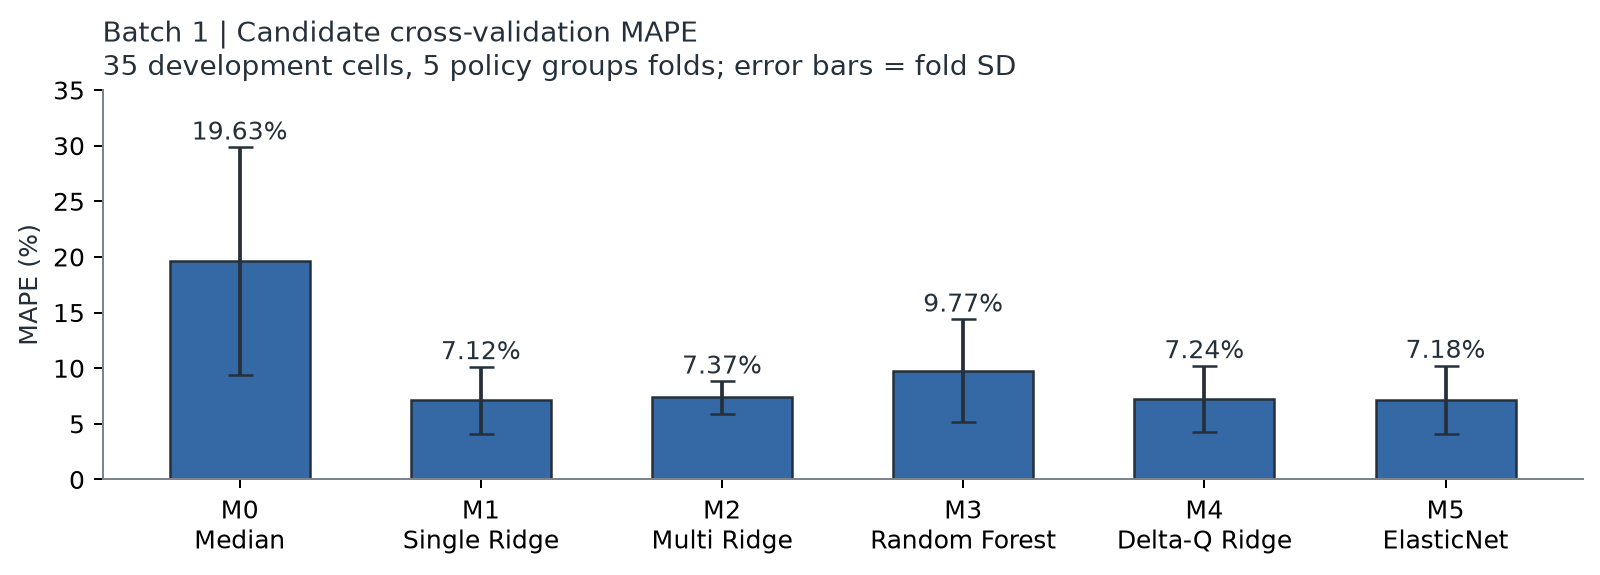

In [7]:
build_charts(features,cv_comparison,locked,predictions,DAY2_OUT/'charts')
diagnose(features,predictions,DAY2_OUT)
display(Image(filename=str(DAY2_OUT/'charts/batch1_candidates.png')))

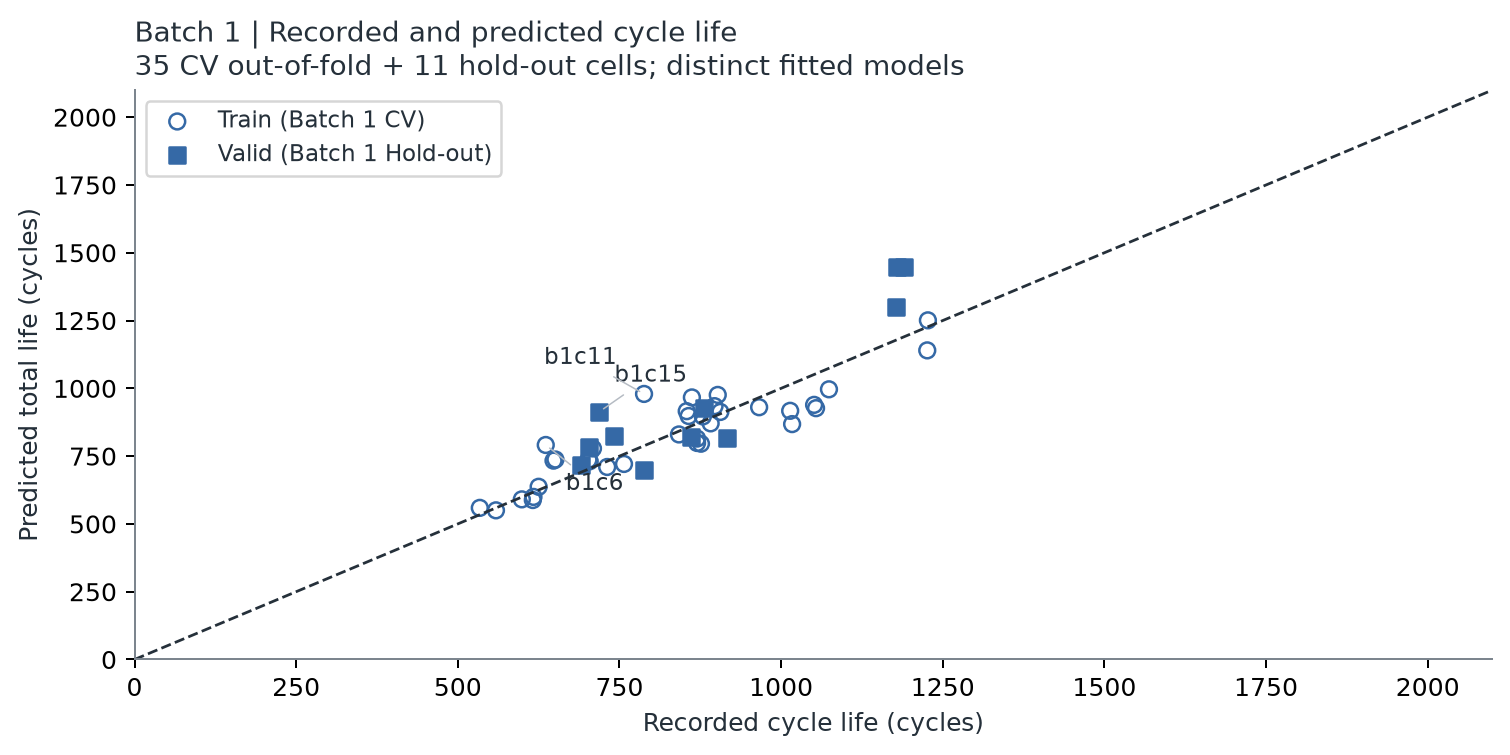

In [8]:
display(Image(filename=str(DAY2_OUT/'charts/batch1_prediction.png')))

**Batch 1:** 정책이 다른 Hold-out에서는 MAPE가 12.72% 로 증가한다. b1c0·b1c1 은 실제 1179–1190 사이클보다 약 1448 사이클로 높게 추정된다. 개발 35 셀의 CV만으로 새로운 운전 정책의 정확도를 설명하면 낙관적일 수 있다.

**시사점:** 정책이 다른 셀을 검증에서 분리하는 것이 실제 적용 질문에 더 가깝다. 임의 셀 분할의 점수보다 정책 단위 오차를 모델 채택 근거로 사용한다. 작은 Hold-out의 차이를 과적합 하나로 확정하지 않는다.

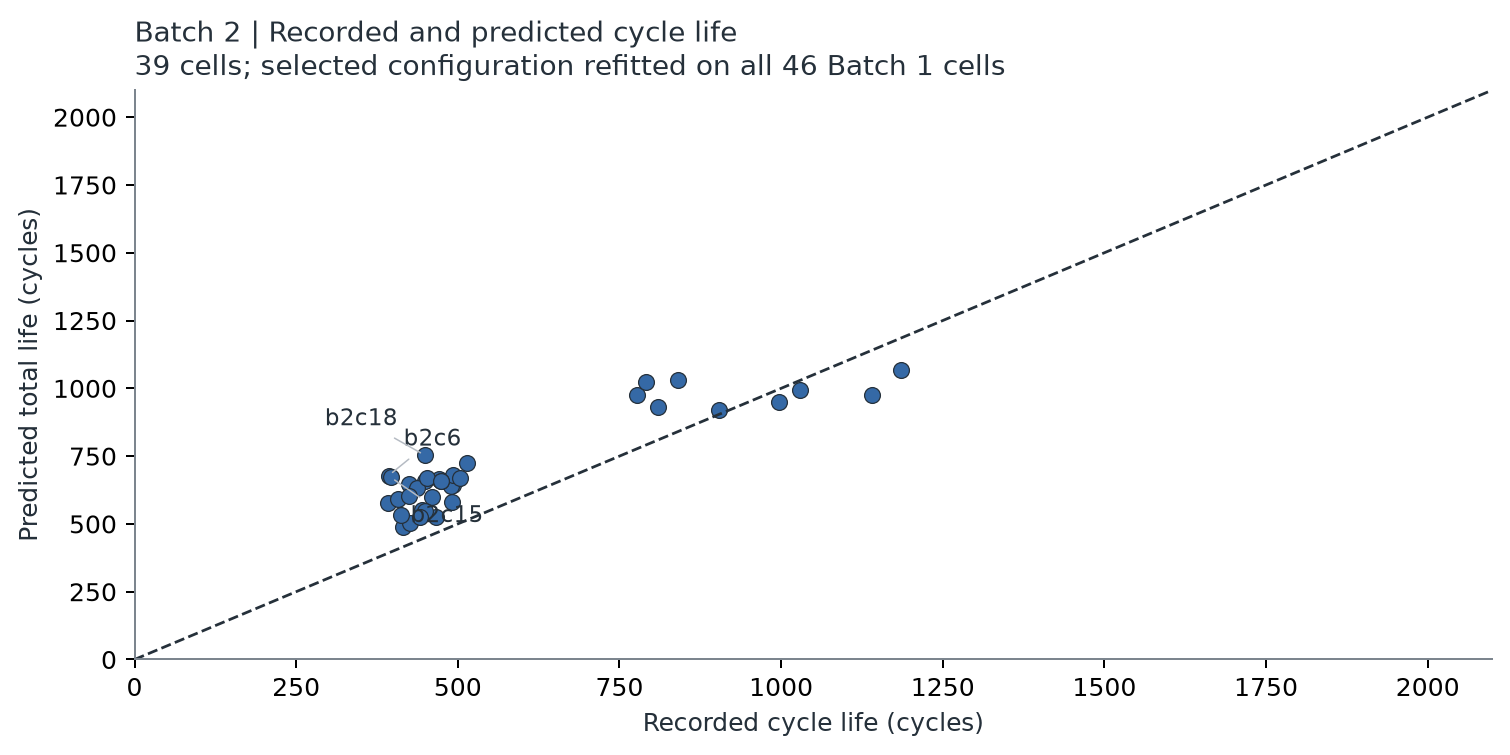

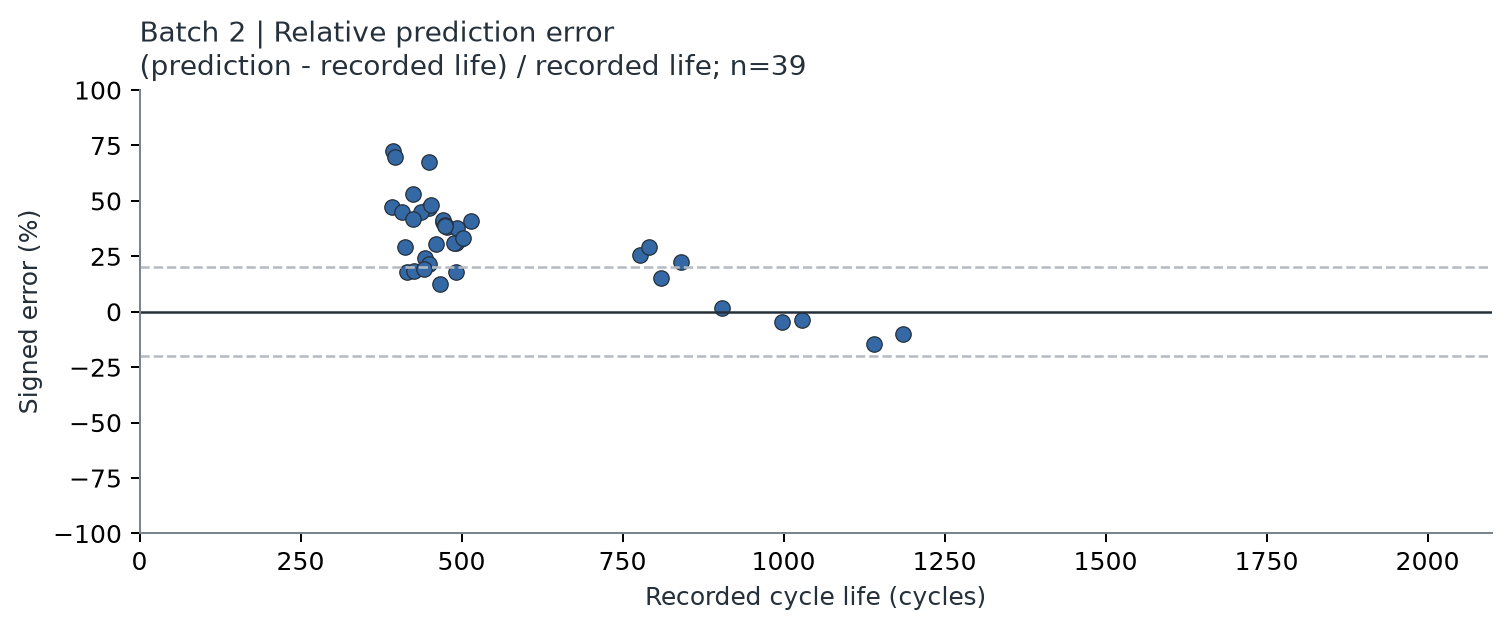

In [9]:
display(Image(filename=str(DAY2_OUT/'charts/batch2_prediction.png')))
display(Image(filename=str(DAY2_OUT/'charts/batch2_errors.png')))

**Batch 2:** 39 셀 중 35 셀(89.74%)에서 수명을 과대 예측하며 28 셀(71.79%)은 실제보다 20% 이상 높다. Batch 1 최단수명 534 사이클보다 짧은 30 셀의 MAPE가 37.81% 이고, 학습 수명 범위 9 셀은 14.14% 다. 입력 ΔQ는 학습 범위 안에 있어도 수명으로 변환하는 관계가 달라질 수 있다. 점검을 늦추는 방향의 오차가 집중되므로 교체 일정의 자동 결정에는 교정과 별도 검증이 필요하다.

**판단 기준:** 단수명 과대 예측을 별도 손실로 평가하고 완전한 EOL을 가진 짧은 수명 개발 표본을 확보한다. 실제 수명 구간은 평가 후 알게 되는 진단값이다. 운영에서는 새 셀의 수명을 미리 알 수 없으므로 정책·구조·온도와 교정 불확실성을 함께 확인한다.

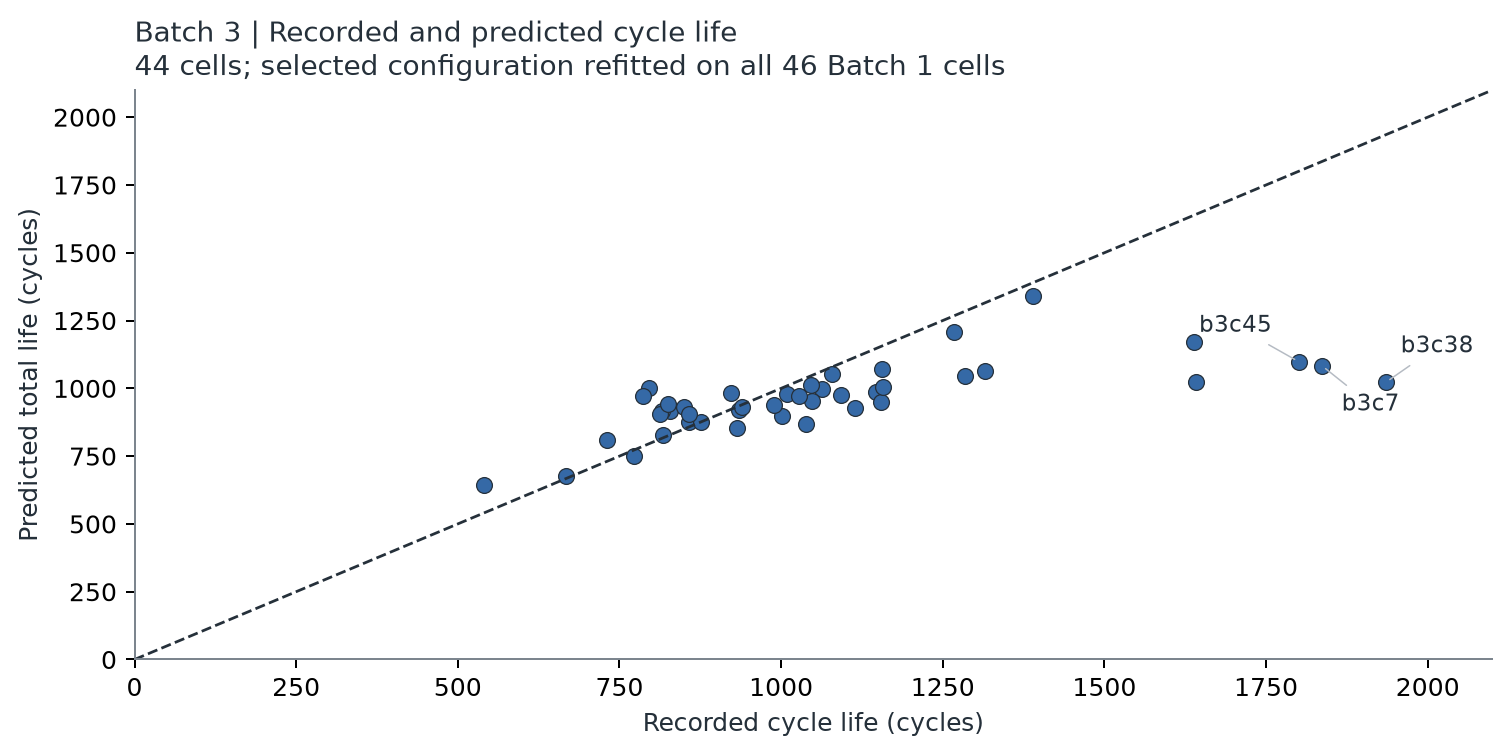

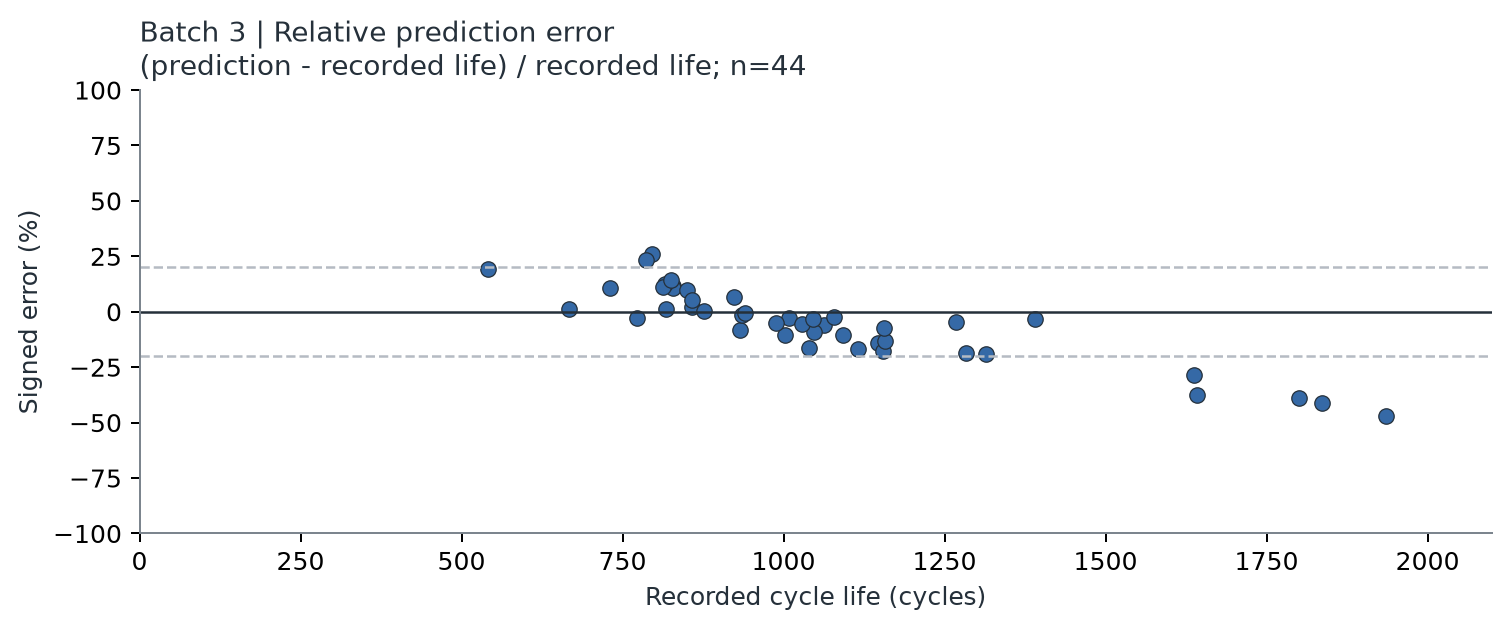

In [10]:
display(Image(filename=str(DAY2_OUT/'charts/batch3_prediction.png')))
display(Image(filename=str(DAY2_OUT/'charts/batch3_errors.png')))

**Batch 3:** MAPE12.74% 만 보면 개선처럼 보이지만 MAE159.41 사이클은 Batch 2 의 159.28 사이클과 비슷하다. 학습 최대 1227 사이클을 초과하는 9 셀의 MAPE26.59%, MAE450.26 사이클이며 9 셀 모두 과소 예측이다. 학습 수명 범위 35 셀의 MAPE는 9.17% 다. 장수명 영역의 교체를 지나치게 앞당기는 오차가 있으므로 평균 상대 오차와 별개로 긴 수명의 적용 범위를 검증해야 한다.

**시사점:** 상대 오차의 낮은 값과 긴 수명 영역의 신뢰성을 구분한다. 장수명 표본 확보와 구간별 bias·예측구간 검증이 교체 계획의 정확성을 판단할 기준이다. 조기 교체는 오차 방향에서 예상하는 가능성이며 실제 교체 비용을 측정한 결과는 아니다.

## 8. 큰 오차의 공통 조건과 적용 범위

In [11]:
display(pd.read_csv(DAY2_OUT/'worst_cells.csv').query('batch in [2,3]')[['role','cell_id','charging_policy','cycle_life','prediction','APE_pct']].round(2))
display(pd.read_csv(DAY2_OUT/'lifetime_range_errors.csv').round(3))

,role,cell_id,charging_policy,cycle_life,prediction,APE_pct
0,Test (Batch 2),b2c6,3.6C(9%)-5C,393.0,678.19,72.57
1,Test (Batch 2),b2c15,3.6C(9%)-5C,396.0,672.36,69.79
2,Test (Batch 2),b2c18,5.2C(50%)-4.25C,449.0,753.23,67.76
3,Test (Batch 2),b2c2,5.2C(50%)-4.25C,424.0,648.65,52.98
4,Test (Batch 2),b2c29,5.2C(58%)-4C,452.0,668.97,48.00
5,Test (Batch 3),b3c38,5C(67%)-4C-newstructure,1935.0,1021.92,47.19
6,Test (Batch 3),b3c7,4.8C(80%)-4.8C-newstructure,1836.0,1084.01,40.96
7,Test (Batch 3),b3c45,4.8C(80%)-4.8C-newstructure,1801.0,1097.61,39.06
8,Test (Batch 3),b3c42,4.8C(80%)-4.8C-newstructure,1642.0,1023.67,37.66
9,Test (Batch 3),b3c16,4.8C(80%)-4.8C-newstructure,1638.0,1171.12,28.50


,role,stratum,n,MAPE_pct,MAE_cycles,bias_cycles,Spearman_all
0,Train (Batch 1 CV),all,35,7.190,59.866,0.247,0.867
1,Train (Batch 1 CV),within_train_lifetime,35,7.190,59.866,0.247,0.867
2,Valid (Batch 1 Hold-out),all,11,12.722,118.612,77.593,0.745
3,Valid (Batch 1 Hold-out),within_train_lifetime,11,12.722,118.612,77.593,0.745
4,Test (Batch 2),all,39,32.347,159.275,140.489,0.709
5,Test (Batch 2),below_train_lifetime,30,37.809,169.486,169.486,0.709
6,Test (Batch 2),within_train_lifetime,9,14.139,125.239,43.832,0.709
7,Test (Batch 3),all,44,12.736,159.406,-100.318,0.797
8,Test (Batch 3),above_train_lifetime,9,26.590,450.264,-450.264,0.797
9,Test (Batch 3),within_train_lifetime,35,9.173,84.614,-10.331,0.797


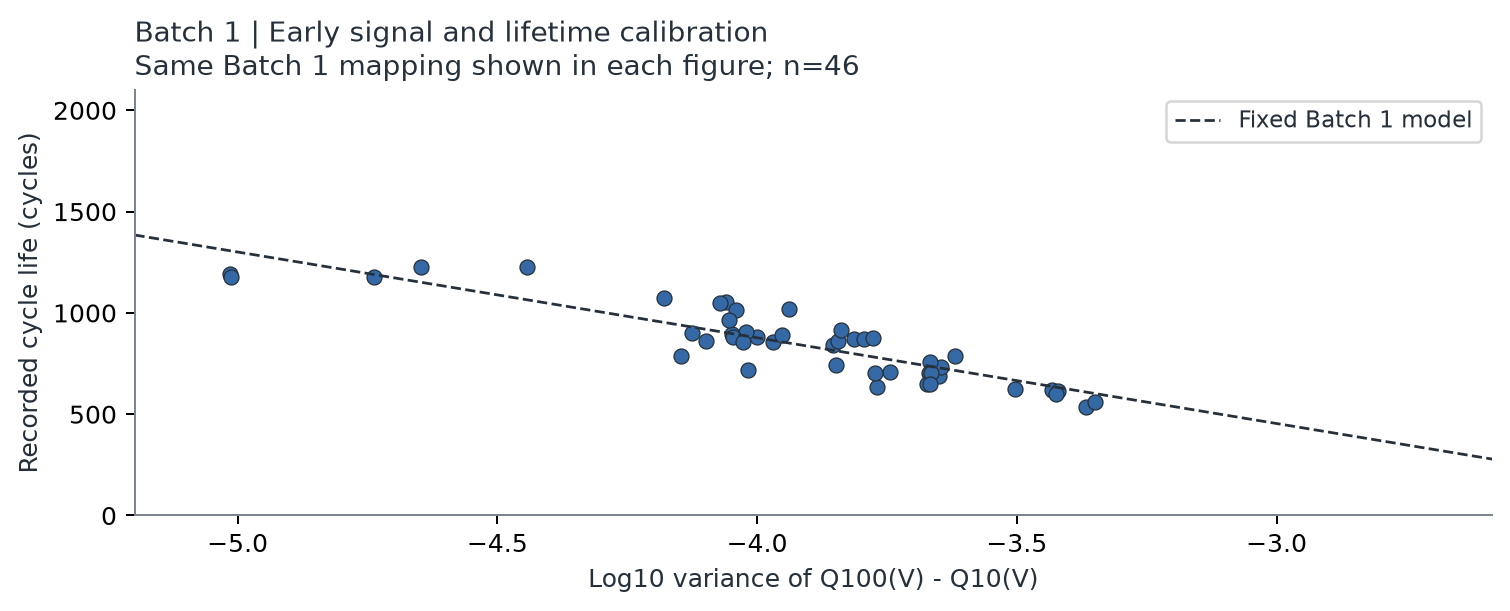

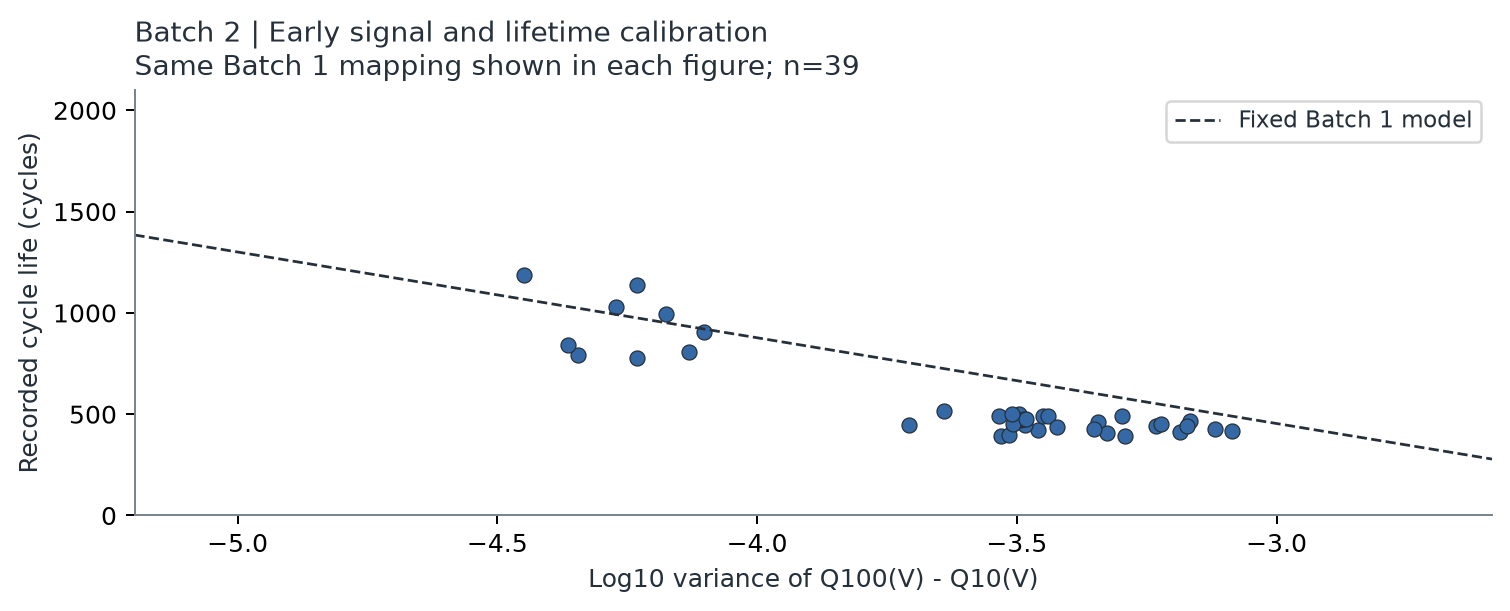

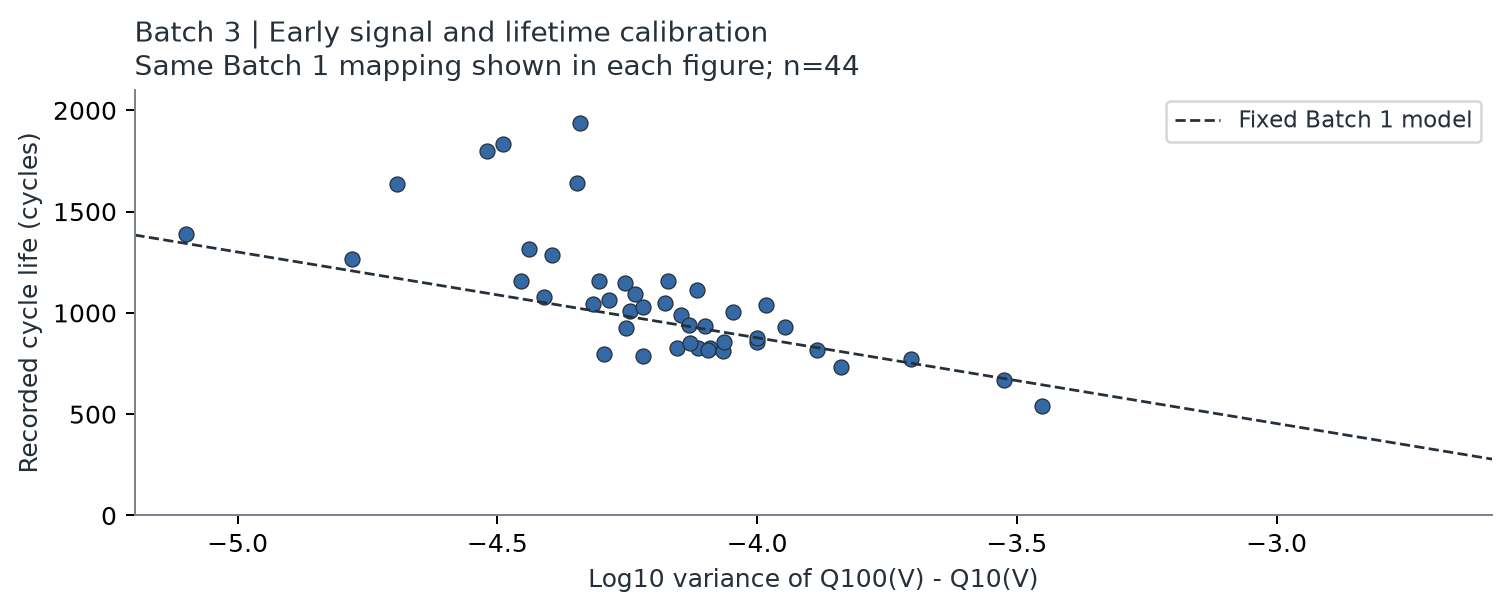

In [12]:
display(Image(filename=str(DAY2_OUT/'charts/batch1_signal_mapping.png')))
display(Image(filename=str(DAY2_OUT/'charts/batch2_signal_mapping.png')))
display(Image(filename=str(DAY2_OUT/'charts/batch3_signal_mapping.png')))

큰 오차는 단순히 입력 범위를 벗어난 셀에만 생기지 않는다. Batch 2 의 b2c6·b2c15(3.6C(9%)-5C)와 b2c18(5.2C(50%)-4.25C)은 ΔQ가 학습 범위에 있어도 실제 수명이 393–449 사이클로 짧다. Batch 3 의 b3c38·b3c7·b3c45 는 newstructure 정책과 1801–1935 사이클 장수명 영역에서 과소 예측이 나타난다. 정책·셀 구조·수집 시기의 차이는 원인 가설이며 관찰 자료만으로 인과 효과를 확정할 수 없다.

**범위 진단:** Batch 2 전체가 학습 입력 범위 안에 있는 것은 아니다. ΔQ가 Batch 1 범위 안에 있는 28/39셀에서도 MAPE34.90%, 평균 편향+152.09사이클이 남는다. 따라서 단순 입력 최소·최대 검사는 정확도 보장이 될 수 없다. 정책·구조별 대응 관계를 새 검증 집단에서 확인하는 것이 다음 개발의 우선순위다.

## 9. 데이터 품질 민감도와 해석 한계

In [13]:
quality_rules=pd.read_csv(MODEL_PROJECT_DIR/'data/processed/batch3_author_quality_rules.csv')
display(quality_sensitivity(predictions,quality_rules,DAY2_OUT).round(3))
display(pd.read_csv(DAY2_OUT/'holdout_permutation_importance.csv').round(3))

,cohort,n,MAPE_pct,MAE_cycles
0,all finite targets,44,12.736,159.406
1,"author-rule quality sensitivity, same locked m...",40,12.781,156.326


,feature,MAPE_increase_pp,SD_pp
0,logvar_deltaQ,17.156,4.864


저자 LoadData.m의 Batch 3 순서를 대응시켜 b3c37(수집 문제), b3c2·b3c42·b3c43(잡음 규칙)을 표기했다. 같은 고정 모델의 품질 민감도 40 셀 MAPE는 12.78% 로 44 셀 12.74% 와 유사하다. 품질 필터만으로 배치 일반화 문제가 해결된다고 볼 근거는 약하다. 주 평가는 탐색적 분석과 같은 유효 타깃 코호트다.

Batch 1 의 13 셀은 종료 용량이 0.885Ah보다 높아 기록된 cycle_life를 물리적 80% EOL로 곧바로 해석하기 어렵다. barcode/channel 필드는 MATLAB 객체 참조 형식이어서 파일 간 물리 셀 동일성을 이 분석으로 검증하기 어렵다. 고유 cell_id는 파일·행 수준 식별자다. 독립 셀 확인과 완료된 EOL 라벨 확보가 성능 해석의 중요한 전제다.

**시사점:** 정제는 측정 오류를 바로잡는 작업이어야 한다. EDA에서 Batch 2 IQR 표시 9셀을 일괄 제거하면 장수명>1000의 3셀이 모두 사라졌다. 정상적인 극단 수명까지 없애면 적용 범위를 좁힌 채 점수를 평가하게 된다. 라벨·측정 이력 검토와 수명 영역별 표본 보존을 우선한다.

## 10. ESS 운영 의사결정과 개선 우선순위

Batch 2·3 의 수명 순위 Spearman은 0.709·0.797 로, 절대 수명보다 상대적 우선순위에 활용 가능성이 있다. 이 상관은 상위 위험 셀 탐지율이나 현장 비용 효과를 보장하지 않는다. 기업 적용에서는 동일 셀 구조·운전 조건에서 점검 우선순위의 hit rate, 과대 예측 비용, 새 배치의 교정 성능을 별도로 검증해야 한다.

우선순위는 (1) EOL까지 관측한 단수명·장수명 셀 및 신뢰 가능한 물리ID 확보, (2) 정책과 셀 구조별 교정 효과를 신규 검증 집단에서 확인, (3) 온도·SOC·DoD·캘린더 열화와 팩 편차가 있는 현장 데이터 검증이다. 현재 테스트를 다시 튜닝 자료로 사용하면 수정 모델의 최종 판단에는 새로운 테스트 집단이 필요하다. 피처를 무작정 늘리기보다 적용 영역을 넓히고 오차 방향을 관리하는 것이 이번 결과에서 도출한 개발 판단이다.

**적용 판단:** 상대 점검 순위는 예산별 위험 셀 적중률로, 절대 교체 일정은 구간별 편향과 오류 비용으로 검증한다. 순위 상관이 남는다는 관찰을 현장 적용 효과로 확대하지 않는다. 이번 결과의 실무 가치는 어떤 목적에 어떤 검증이 필요한지 구분한 데 있다.

## 11. 실행 결과 검증

In [14]:
assert len(predictions)==129 and predictions.cell_id.is_unique
assert set(locked['features']).isdisjoint({'cycle_life','eol_near','tail_median_QD','summary_cycles'})
assert len(cv_comparison)==len(candidate_specs())==275
assert performance.loc[performance.role=='Test (Batch 2)','n'].iloc[0]==39
assert performance.loc[performance.role=='Test (Batch 3)','n'].iloc[0]==44
print('정책 분리, 초기 피처, 129셀 예측, 후보 설정 및 배치별 평가 검증 완료')
from src.artifact import export_model, predict_artifact
model_artifact=export_model(features,locked,DAY2_OUT)
test_predictions=predictions[predictions.batch.isin([2,3])]
np.testing.assert_allclose(predict_artifact(test_predictions,model_artifact),test_predictions.prediction,rtol=1e-12,atol=1e-9)
print("학습된 JSON 모델과 테스트 예측 일치")

정책 분리, 초기 피처, 129셀 예측, 후보 설정 및 배치별 평가 검증 완료
학습된 JSON 모델과 테스트 예측 일치


## 12. 시사점의 근거와 의사결정 기준

아래 표는 피처·후보 비교·고정 평가 결과를 읽어 **관찰 → 해석 → 판단 → 해석 조건**으로 연결한다. 점수를 다시 최적화하거나 모델 선택에 되돌려 사용하는 단계가 아니다. 숫자를 수정해 문장을 맞추는 대신, 결과가 바뀌면 같은 계산에서 근거가 갱신된다.

I1: 배치 차이와 신호 · I2: 추가 입력의 증분 가치 · I3: 오차 방향 · I4: 적용 범위 · I5: 품질과 표본 보존 · I6: 활용 목적.

In [15]:
from src.insights import save_insight_evidence
insight_evidence = save_insight_evidence(MODEL_PROJECT_DIR, DAY2_OUT)
# 관찰 수치와 판단을 먼저 읽고, 해석 조건을 별도 표에서 확인합니다.
with pd.option_context('display.max_colwidth', None):
    display(insight_evidence[['id', '핵심 발견', '관찰 근거', '의사결정 시사점']])
    display(insight_evidence[['id', '해석', '해석 조건']])
assert len(insight_evidence) == 6 and insight_evidence.id.is_unique
print('6개 시사점의 근거·판단 기준 저장: results/insight_evidence.csv')

,id,핵심 발견,관찰 근거,의사결정 시사점
0,I1,절대 용량보다 변화량에 남는 수명 신호,"QD2-수명 r: 전체 -0.525, 배치 중심화 -0.013; ΔQ 로그 분산-수명 r: 전체 -0.851, 중심화 -0.773","전체 상관 순위만으로 피처를 고르지 않고, 변화량 신호를 기준으로 정책 그룹 검증에서 추가 입력의 기여를 비교한다."
1,I2,센서 추가의 기여와 모델 복잡도의 구분,"M1 단일 Ridge 7.12%, M2 다변량 Ridge 7.37%, M3 RF 9.77%, M4 ΔQ 확장 Ridge 7.24%, M5 ElasticNet 7.18%; M2 폴드 SD 1.45%p, M1 3.00%p",단일 ΔQ Ridge를 유지한다. 추가 센서 수집·비선형 모델 도입은 같은 분할에서의 증분 가치로 판단한다. 낮은 M2 변동성은 추가 표본에서 재검토한다.
2,I3,평균 상대 오차가 가리는 운영 위험의 방향,"Batch 2/3 MAE 159.28/159.41사이클, MAPE 32.35/12.74%; Batch 2 과대 예측 35/39셀","점검 지연 위험은 단수명 과대 예측, 조기 교체 위험은 장수명 과소 예측으로 구분해 수명 구간별 MAE·bias와 오류 비용을 평가한다."
3,I4,입력 범위 검사만으로 확인하기 어려운 적용 영역,"Batch 2 ΔQ 학습 범위 안 28/39셀, 해당 MAPE 34.90%; 학습 최단수명 미만 30셀 MAPE 37.81%; Batch 3 학습 최대수명 초과 9셀 MAE 450.26사이클",정책·셀 구조·수집 조건을 포함한 새 검증 집단과 단수명·장수명 개발 표본을 확보한다. 입력 범위 안이라는 이유만으로 자동 결정을 허용하지 않는다.
4,I5,품질 검토와 예측 대상 축소의 구분,"Batch 2 IQR 제외 표시 9셀; 장수명>1000 3→0셀; Batch 3 품질 민감도 44→40셀, MAPE 12.74→12.78%","품질 문제는 측정 이력으로 판단하고, 정상적인 극단 수명은 검증 대상으로 보존한다. 정제보다 라벨 완료 여부와 표본 범위를 먼저 점검한다."
5,I6,절대 교체 시점과 상대 점검 순위의 분리,Batch 2/3 수명 순위 Spearman 0.709/0.797,"점검 우선순위의 적용 가능성을 상위 위험 셀 탐지율·예산별 적중률로 별도 검증하고, 교체 자동 결정은 수명 구간별 교정과 현장 검증 이후 판단한다."


,id,해석,해석 조건
0,I1,전체 상관에는 배치 평균 차이가 섞인다. ΔQ의 관계는 배치 평균을 구분한 뒤에도 유지된다.,중심화는 배치 수준 평균을 구분하는 진단이며 운전 조건의 인과 효과를 제거하는 실험이 아니다.
1,I2,추가 센서 묶음은 평균 오차를 개선하지 못했다. ΔQ 최솟값의 추가와 ElasticNet도 단일 기준보다 평균 오차를 낮추지 못했다. 높은 상관은 피처 중복의 단서이며 증분 가치는 실제 검증으로 판단한다.,개발 35셀의 조건부 비교다. 작은 성능 차이가 통계적으로 유의하거나 다른 배치에서도 유지된다고 단정하지 않는다.
2,I3,MAPE의 분모가 되는 실제 수명 규모가 다르다. 낮은 상대 오차만으로 다른 배치의 운영 적합성이 더 좋다고 판단하기 어렵다.,점검 지연·조기 교체는 오차 방향에 따른 가능성이다. 실제 비용과 현장 교체 결과는 측정하지 않았다.
3,I4,입력이 익숙한 범위여도 수명과의 대응 관계가 달라질 수 있다. 학습 수명 범위의 양쪽 끝에서 큰 오차가 남는다.,"실제 수명 구간은 사후 진단이다. 운영에서는 새 셀의 정답 수명을 미리 알 수 없고, 정책·구조·불확실성 등 관측 가능한 정보가 필요하다."
4,I5,일괄 이상치 제거는 중요한 수명 영역을 없앨 수 있다. 저자 품질 규칙을 대응시킨 검토에서도 외부 오차가 크게 줄지 않았다.,IQR은 타깃 분포의 진단이며 실제 셀 삭제나 초기 시점의 품질 판정 규칙으로 사용하지 않았다.
5,I6,절대 수명에 편향이 남아도 순위 정보는 일부 유지된다. 가능한 활용 목적에 따라 검증 기준이 달라진다.,순위 상관은 위험 셀 탐지 성능이나 비용 절감의 검증 결과가 아니다. 현장 적용은 별도 실험이 필요하다.


6개 시사점의 근거·판단 기준 저장: results/insight_evidence.csv
